# Example 04: Decaying signals — Lorentzian fitting

A decaying signal $x(t) = A\cos(2\pi f_0 t + \varphi)\,e^{-\gamma t}$ has fixed total energy. The **CFT normalization** is appropriate because it preserves $x(0)$ regardless of record length, giving a physically meaningful peak amplitude. ASD normalization is designed for stationary signals and its peak value scales with acquisition length — not a useful quantity for a decaying transient.

The Fourier transform of such a signal is a **complex Lorentzian pair**; near $f_0$ on the positive-frequency side: $X(f) \approx \frac{A/2}{\gamma + 2\pi j(f - f_0)}$. `SineFourier` implements the exact analytical DFT expression, including corrections for window truncation, baseline discontinuity, and aliasing.

**Fitted parameters:** frequency $f_0$, amplitude $A$, phase $\varphi$, decay rate $\gamma$, and FWHM $= \gamma/\pi$. Internally the model uses quadrature components $A_i = A\cos\varphi$, $A_q = A\sin\varphi$, which are linear in the data and improve numerical conditioning.

*Implementation: `SineFourier` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

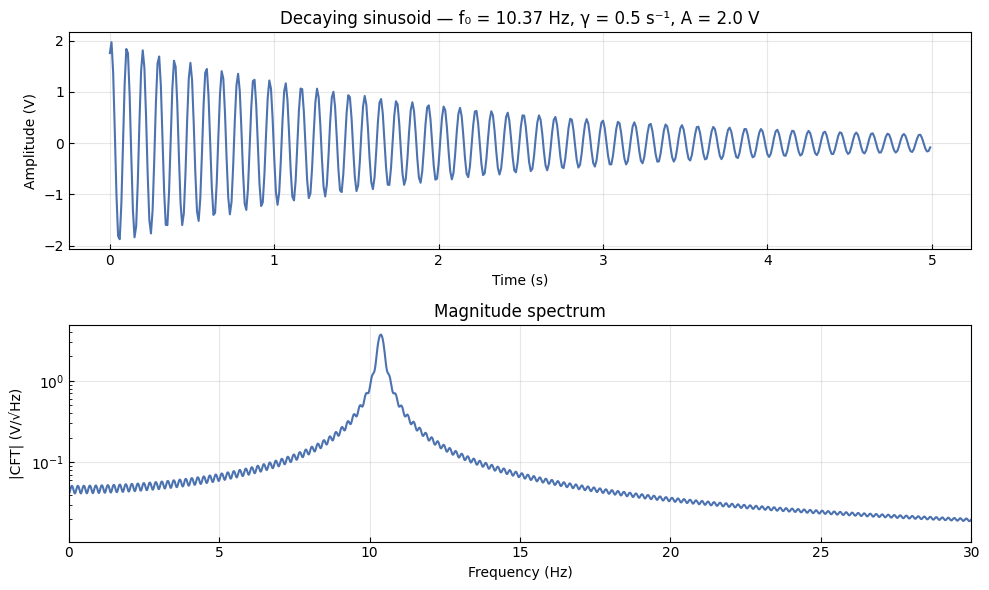

In [2]:
# Imports, constants, time-domain signal and CFT spectrum
import numpy as np
import lmfit
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
plt.style.use("dftmodels.mplstyle")

from dftmodels import (
    SignalSeries, NormType, WindowType, DFTRange, DFTCorrection, DFTCorrectionMode,
    Sinusoid, SineFourier,
)

SAMPLE_RATE    = 100.0   # Hz
DURATION       = 5.0     # s
TRUE_AMPLITUDE = 2.0     # V
TRUE_FREQUENCY = 10.37   # Hz
TRUE_PHASE     = 0.5     # rad
TRUE_DECAY     = 0.5     # s⁻¹
TRUE_FWHM      = TRUE_DECAY / np.pi   # Hz

WINDOW    = WindowType.RECTANGULAR
N_MC      = 300
NOISE_STD = 0.05   # V

ai = TRUE_AMPLITUDE * np.cos(TRUE_PHASE)
aq = TRUE_AMPLITUDE * np.sin(TRUE_PHASE)

t      = np.arange(0, DURATION, 1.0 / SAMPLE_RATE)
y      = Sinusoid.eval(t, ai, aq, TRUE_FREQUENCY, TRUE_DECAY)
signal = SignalSeries(x=t, y=y)

fourier = signal.calculate_dft(
    norm=NormType.CFT,
    window=WINDOW,
    dft_range=DFTRange.SINGLE_SIDED,
    pad=10.0,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t, y)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (V)")
axes[0].set_title(
    f"Decaying sinusoid — f₀ = {TRUE_FREQUENCY} Hz, "
    f"γ = {TRUE_DECAY} s⁻¹, A = {TRUE_AMPLITUDE} V"
)

axes[1].plot(fourier.x, np.abs(fourier.y))
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("|CFT| (V/√Hz)")
axes[1].set_title("Magnitude spectrum")
axes[1].semilogy()
axes[1].set_xlim(0, 30)

plt.tight_layout()
plt.savefig(f"figures/04_decaying_signals_fig00.svg", bbox_inches="tight")
plt.show()

## Naive linewidth estimation

Two simple estimators recover $\gamma$ directly from the magnitude spectrum, without a parametric model or DFT corrections:

- **Half-height crossing.** The power spectrum $|X(f)|^2$ of a decaying sinusoid is approximately Lorentzian with FWHM $= \gamma/\pi$. The half-maximum of the power spectrum occurs at $|X(f)| = |X(f_0)|/\sqrt{2}$. Find where the magnitude spectrum crosses this threshold (linearly interpolated between bins) and set $\gamma = \pi \cdot \text{FWHM}$.
- **Quadratic interpolation.** Fit a parabola to the three bins of $|X(f)|^2$ surrounding the peak. The curvature yields a sub-bin estimate of the half-power width: $\text{FWHM} = 2\sqrt{-y_\text{peak}/(2c_2)}$, where $c_2$ is the second-order coefficient.

Both methods are biased because the DFT of a *finite-duration* signal is not a perfect Lorentzian — window truncation distorts the spectral shape and shifts the apparent linewidth.

Method                         γ (s⁻¹)   error (s⁻¹)
----------------------------------------------------
True                            0.5000
Half-height crossing            0.6671       +0.1671
Quadratic (power)               0.5709       +0.0709


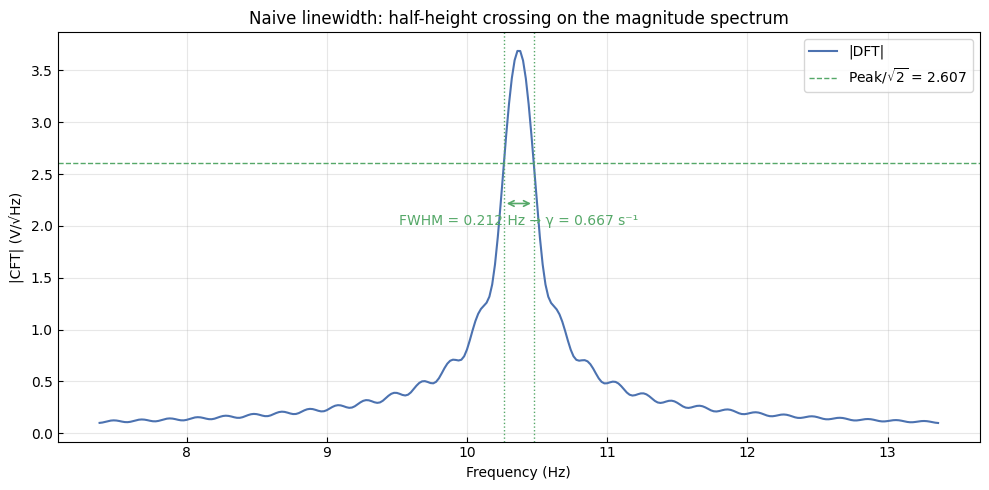

In [3]:
# Naive linewidth estimation: half-height crossing and quadratic interpolation
zoom_n  = (fourier.x >= TRUE_FREQUENCY - 3) & (fourier.x <= TRUE_FREQUENCY + 3)
f_z     = fourier.x[zoom_n]
mag_z   = np.abs(fourier.y[zoom_n])
pow_z   = mag_z**2
df      = fourier.x[1] - fourier.x[0]

peak_i  = int(np.argmax(mag_z))
mag_pk  = mag_z[peak_i]

# Method 1 — half-height crossing at |DFT| = peak/√2  (power half-maximum → FWHM = γ/π)
threshold = mag_pk / np.sqrt(2)

li = peak_i
while li > 0 and mag_z[li] > threshold:
    li -= 1
t_l = (threshold - mag_z[li]) / (mag_z[li + 1] - mag_z[li])
f_l = f_z[li] + t_l * (f_z[li + 1] - f_z[li])

ri = peak_i
while ri < len(mag_z) - 1 and mag_z[ri] > threshold:
    ri += 1
t_r = (threshold - mag_z[ri - 1]) / (mag_z[ri] - mag_z[ri - 1])
f_r = f_z[ri - 1] + t_r * (f_z[ri] - f_z[ri - 1])

gamma_crossing = np.pi * (f_r - f_l)

# Method 2 — quadratic fit to power spectrum (3-point parabola, sub-bin width)
if 0 < peak_i < len(f_z) - 1:
    yl, yp, yr = pow_z[peak_i - 1], pow_z[peak_i], pow_z[peak_i + 1]
    c2         = (yl - 2 * yp + yr) / (2 * df**2)
    gamma_quad = np.pi * 2 * np.sqrt(-yp / (2 * c2))
else:
    gamma_quad = gamma_crossing

print(f"{'Method':<26}  {'γ (s⁻¹)':>10}  {'error (s⁻¹)':>12}")
print("-" * 52)
print(f"{'True':<26}  {TRUE_DECAY:>10.4f}")
print(f"{'Half-height crossing':<26}  {gamma_crossing:>10.4f}  {gamma_crossing - TRUE_DECAY:>+12.4f}")
print(f"{'Quadratic (power)':<26}  {gamma_quad:>10.4f}  {gamma_quad - TRUE_DECAY:>+12.4f}")

# Annotated spectrum
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f_z, mag_z, label="|DFT|")
ax.axhline(threshold, ls="--", color="C1", lw=1.0, label=f"Peak/$\\sqrt{{2}}$ = {threshold:.3f}")
ax.axvline(f_l, ls=":", color="C1", lw=1.0)
ax.axvline(f_r, ls=":", color="C1", lw=1.0)
ax.annotate("", xy=(f_r, threshold * 0.85), xytext=(f_l, threshold * 0.85),
            arrowprops=dict(arrowstyle="<->", color="C1", lw=1.2))
ax.text((f_l + f_r) / 2, threshold * 0.77,
        f"FWHM = {f_r - f_l:.3f} Hz → γ = {gamma_crossing:.3f} s⁻¹",
        ha="center", color="C1")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("|CFT| (V/√Hz)")
ax.set_title("Naive linewidth: half-height crossing on the magnitude spectrum")
ax.legend()
plt.tight_layout()
plt.savefig(f"figures/04_decaying_signals_fig01.svg", bbox_inches="tight")
plt.show()

## Lorentzian fit with corrections

Fit the decaying signal with `SineFourier` using all corrections. The complex spectrum (real + imaginary) provides twice the constraints per frequency bin compared to magnitude-only fitting.

The three DFT corrections (WINDOW, BASELINE, SAMPLING) and their origins are derived in detail in [notebook 02](./02_dft_corrections.ipynb). Here we only show their effect: fitting the bare Lorentzian (exact CFT solution) versus the fully corrected model.

In [4]:
# Monte Carlo simulation comparing bare vs corrected Lorentzian fit
bare_correction = DFTCorrection(DFTCorrectionMode.NONE, order=0)
bare_model      = SineFourier(fourier.dft_config, bare_correction)

full_correction = DFTCorrection(DFTCorrectionMode.ALL, order=10)
full_model      = SineFourier(fourier.dft_config, full_correction)

_init = dict(  # initial guesses perturbed from true values
    amplitude_i=ai * 1.1,
    amplitude_q=aq * 1.1,
    frequency=TRUE_FREQUENCY * 1.02,
    decay=TRUE_DECAY * 1.1,
    frequency_min=0.0,
    frequency_max=100.0,
)

rng = np.random.default_rng(seed=12345)

amp_errs_bare,   amp_errs_corr   = [], []
phase_errs_bare, phase_errs_corr = [], []
freq_errs_bare,  freq_errs_corr  = [], []
decay_errs_bare, decay_errs_corr = [], []

for _ in range(N_MC):
    noise      = rng.normal(0.0, NOISE_STD, size=len(y))
    signal_mc  = SignalSeries(x=t, y=y + noise)
    fourier_mc = signal_mc.calculate_dft(
        norm=NormType.CFT, window=WINDOW,
        dft_range=DFTRange.SINGLE_SIDED, pad=10.0,
    )

    bare_result = bare_model.fit(fourier_mc, bare_model.make_params(**_init))
    full_result = full_model.fit(fourier_mc, full_model.make_params(**_init))

    amp_errs_bare.append(  bare_model.amplitude(bare_result.params) - TRUE_AMPLITUDE)
    amp_errs_corr.append(  full_model.amplitude(full_result.params) - TRUE_AMPLITUDE)

    phase_errs_bare.append(bare_model.phase(bare_result.params) - TRUE_PHASE)
    phase_errs_corr.append(full_model.phase(full_result.params) - TRUE_PHASE)

    freq_errs_bare.append( bare_result.params["frequency"].value - TRUE_FREQUENCY)
    freq_errs_corr.append( full_result.params["frequency"].value - TRUE_FREQUENCY)

    decay_errs_bare.append(bare_result.params["decay"].value - TRUE_DECAY)
    decay_errs_corr.append(full_result.params["decay"].value - TRUE_DECAY)

## Cramér–Rao bounds

The Cramér–Rao bound (CRB) is the minimum variance any unbiased estimator can achieve. For the decaying sinusoid

$$x_n = (a_i\cos 2\pi f t_n + a_q \sin 2\pi f t_n)\,e^{-\gamma t_n} + w_n, \qquad w_n \sim \mathcal{N}(0,\sigma^2),$$

the Fisher information matrix is $\mathbf{I} = J^\top J / \sigma^2$, where $J_{nk} = \partial x_n / \partial \theta_k$ evaluated at the true parameter values $\theta = (a_i, a_q, f, \gamma)$. Unlike the pure sinusoid in example 03, $f$ and $\gamma$ are **not decoupled**: the exponential envelope makes both their gradients proportional to $e^{-\gamma t_n}$, so $I_{f\gamma} \neq 0$ in general. The CRB is $\mathrm{CRB}(\theta_k) = (\mathbf{I}^{-1})_{kk}$; bounds for amplitude and phase are obtained by propagating the $(a_i, a_q)$ covariance block analytically.

The Jacobian is computed numerically from `Sinusoid.eval`.

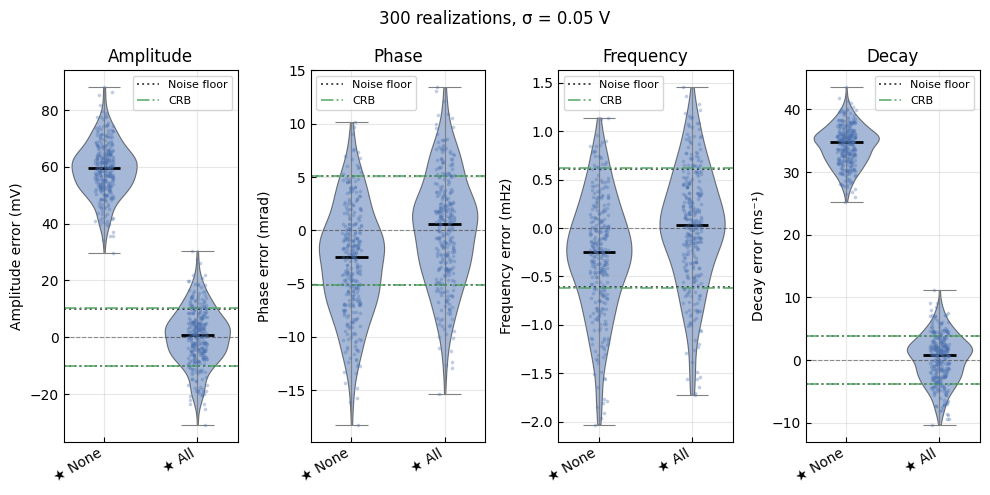

In [5]:
# Cramér–Rao bounds and violin plots
from helpers import violin_panel

_params_crb = Sinusoid.make_params(
    amplitude_i=ai, amplitude_q=aq, frequency=TRUE_FREQUENCY, decay=TRUE_DECAY
)
_crb = Sinusoid.crb(_params_crb, t, NOISE_STD)
crb_amp, crb_phase = _crb["amplitude"], _crb["phase"]
crb_freq, crb_decay = _crb["frequency"], _crb["decay"]

nf_amp   = float(np.std(amp_errs_corr))
nf_phase = float(np.std(phase_errs_corr))
nf_freq  = float(np.std(freq_errs_corr))
nf_decay = float(np.std(decay_errs_corr))

mc_panels = [
    ([np.array(amp_errs_bare)*1e3,   np.array(amp_errs_corr)*1e3],   crb_amp*1e3,   nf_amp*1e3,   "Amplitude error (mV)",   "Amplitude"),
    ([np.array(phase_errs_bare)*1e3, np.array(phase_errs_corr)*1e3], crb_phase*1e3, nf_phase*1e3, "Phase error (mrad)",     "Phase"),
    ([np.array(freq_errs_bare)*1e3,  np.array(freq_errs_corr)*1e3],  crb_freq*1e3,  nf_freq*1e3,  "Frequency error (mHz)",  "Frequency"),
    ([np.array(decay_errs_bare)*1e3, np.array(decay_errs_corr)*1e3], crb_decay*1e3, nf_decay*1e3, "Decay error (ms⁻¹)",     "Decay"),
]

labels = ["★ None", "★ All"]

fig, axes = plt.subplots(1, 4, figsize=(10, 5))
for ax, (errs_pair, crb_val, nf_val, ylabel, title) in zip(axes, mc_panels):
    violin_panel(ax, errs_pair, labels, noise_floor=nf_val, crb=crb_val, ylabel=ylabel, title=title, seed=99)

plt.suptitle(f"{N_MC} realizations, σ = {NOISE_STD} V")
plt.tight_layout()
plt.savefig(f"figures/04_decaying_signals_fig02.svg", bbox_inches="tight")
plt.show()

## Fit stderr vs Monte Carlo std vs CRB

The violin plots show two reference lines. The **noise floor** (dotted, black) is the standard deviation of the corrected model's MC errors — the actual precision achieved. The **CRB** (dash-dot, orange) is the theoretical minimum. For the corrected model, the fit covariance (`fit stderr` below) should track the MC RMSE and approach the CRB; for the bare model, the covariance is dominated by systematic bias and is not a meaningful uncertainty.

*Implementation: `SineFourier.amplitude_stderr`, `SineFourier.phase_stderr` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

In [6]:
# Fit stderr vs Monte Carlo RMSE vs CRB (table)
def rmse(errs):
    return float(np.sqrt(np.mean(np.array(errs) ** 2)))

# Fit stderr from the last MC realization
bare_amp_se   = bare_model.amplitude_stderr(bare_result.params)
bare_phase_se = bare_model.phase_stderr(bare_result.params)
bare_freq_se  = bare_result.params["frequency"].stderr
bare_decay_se = bare_result.params["decay"].stderr

full_amp_se   = full_model.amplitude_stderr(full_result.params)
full_phase_se = full_model.phase_stderr(full_result.params)
full_freq_se  = full_result.params["frequency"].stderr
full_decay_se = full_result.params["decay"].stderr

hdr = f"{'':28}  {'amp (mV)':>9}  {'phase (mrad)':>13}  {'freq (mHz)':>11}  {'decay (ms⁻¹)':>13}"
sep = "-" * len(hdr)
print(hdr); print(sep)
print(f"{'CRB':<28}  {crb_amp*1e3:>9.2f}  {crb_phase*1e3:>13.2f}  {crb_freq*1e3:>11.2f}  {crb_decay*1e3:>13.2f}")
print(sep)
print(f"{'* None           RMSE':<28}  {rmse(amp_errs_bare)*1e3:>9.2f}  {rmse(phase_errs_bare)*1e3:>13.2f}  {rmse(freq_errs_bare)*1e3:>11.2f}  {rmse(decay_errs_bare)*1e3:>13.2f}")
print(f"{'           fit stderr':<28}  {bare_amp_se*1e3:>9.2f}  {bare_phase_se*1e3:>13.2f}  {bare_freq_se*1e3:>11.2f}  {bare_decay_se*1e3:>13.2f}")
print(sep)
print(f"{'* All            RMSE':<28}  {rmse(amp_errs_corr)*1e3:>9.2f}  {rmse(phase_errs_corr)*1e3:>13.2f}  {rmse(freq_errs_corr)*1e3:>11.2f}  {rmse(decay_errs_corr)*1e3:>13.2f}")
print(f"{'           fit stderr':<28}  {full_amp_se*1e3:>9.2f}  {full_phase_se*1e3:>13.2f}  {full_freq_se*1e3:>11.2f}  {full_decay_se*1e3:>13.2f}")

                               amp (mV)   phase (mrad)   freq (mHz)   decay (ms⁻¹)
----------------------------------------------------------------------------------
CRB                               10.20           5.13         0.62           3.87
----------------------------------------------------------------------------------
* None           RMSE             59.98           5.93         0.67          34.41
           fit stderr              5.11           2.46         0.30           1.86
----------------------------------------------------------------------------------
* All            RMSE             10.03           5.14         0.61           3.83
           fit stderr              3.26           1.63         0.20           1.23


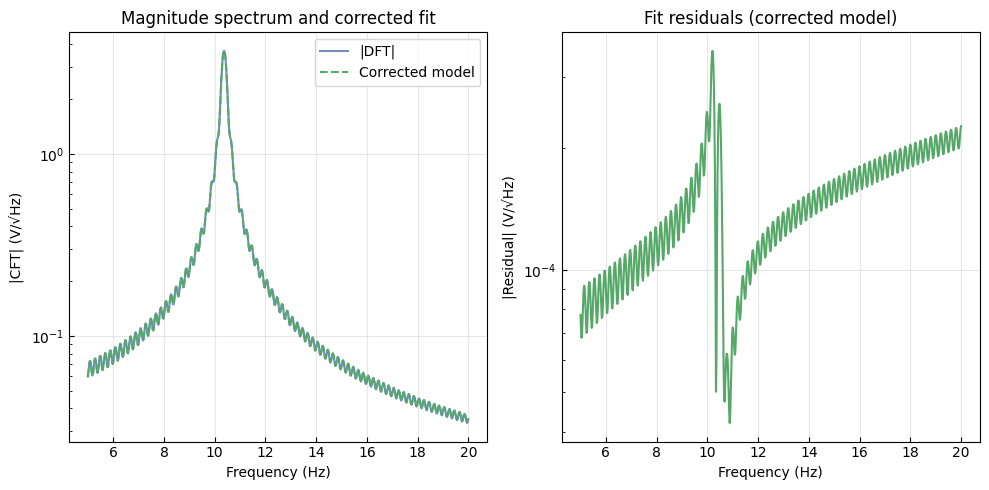

In [7]:
# Clean fit to noiseless signal for residual display
clean_result = full_model.fit(fourier, full_model.make_params(**_init))
y_model      = full_model.eval(clean_result.params, fourier.x)
residuals    = np.abs(fourier.y - y_model)

zoom = (fourier.x >= 5) & (fourier.x <= 20)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(fourier.x[zoom], np.abs(fourier.y[zoom]), alpha=0.8, label="|DFT|")
axes[0].plot(fourier.x[zoom], np.abs(y_model[zoom]), ls="--", label="Corrected model")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("|CFT| (V/√Hz)")
axes[0].set_title("Magnitude spectrum and corrected fit")
axes[0].semilogy()
axes[0].legend()

axes[1].plot(fourier.x[zoom], residuals[zoom], color="C1")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("|Residual| (V/√Hz)")
axes[1].set_title("Fit residuals (corrected model)")
axes[1].semilogy()

plt.tight_layout()
plt.savefig(f"figures/04_decaying_signals_fig03.svg", bbox_inches="tight")
plt.show()

## Exponential window — line broadening

Applying an exponential window $w(t_n) = e^{-\alpha t_n / T}$ before the DFT multiplies the signal by an additional decay, shifting the effective decay rate to $\gamma_\text{eff} = \gamma + \alpha/T$. In NMR spectroscopy this is called *line broadening*: it widens spectral lines and improves SNR for noisy, long-tailed signals at the cost of resolution.

`SineFourier` supports `WindowType.EXPONENTIAL_ASYM` and corrects for the additional window-induced decay, recovering the true $\gamma$ from the broadened spectrum. A bare fit (no window correction) converges to $\gamma_\text{eff}$, biased by $\alpha/T$.

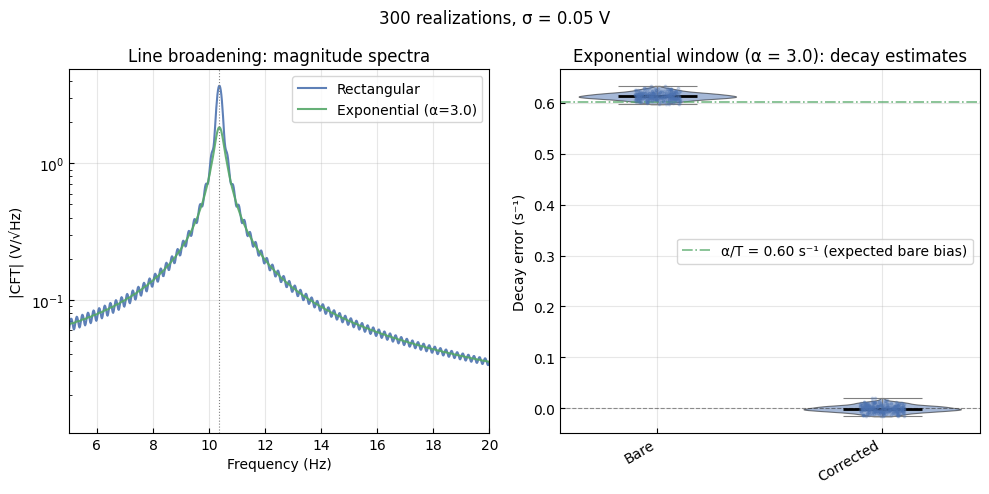

In [8]:
# Exponential window: Monte Carlo decay estimation with and without correction
ALPHA_LB = 3.0   # line-broadening parameter α

fourier_lb = signal.calculate_dft(
    norm=NormType.CFT,
    window=WindowType.EXPONENTIAL_ASYM,
    window_params={"alpha": ALPHA_LB},
    dft_range=DFTRange.SINGLE_SIDED,
    pad=10.0,
)

bare_model_lb = SineFourier(fourier_lb.dft_config, bare_correction)
full_model_lb = SineFourier(fourier_lb.dft_config, full_correction)

_init_lb = dict(  # initial guesses perturbed from true values
    amplitude_i=ai * 1.1,
    amplitude_q=aq * 1.1,
    frequency=TRUE_FREQUENCY * 1.02,
    decay=TRUE_DECAY * 1.1,
    frequency_min=0.0,
    frequency_max=100.0,
)

rng_lb = np.random.default_rng(seed=42)
decay_errs_bare_lb, decay_errs_corr_lb = [], []

for _ in range(N_MC):
    noise_lb      = rng_lb.normal(0.0, NOISE_STD, size=len(y))
    signal_lb     = SignalSeries(x=t, y=y + noise_lb)
    fourier_mc_lb = signal_lb.calculate_dft(
        norm=NormType.CFT,
        window=WindowType.EXPONENTIAL_ASYM,
        window_params={"alpha": ALPHA_LB},
        dft_range=DFTRange.SINGLE_SIDED,
        pad=10.0,
    )
    bare_res_lb = bare_model_lb.fit(fourier_mc_lb, bare_model_lb.make_params(**_init_lb))
    full_res_lb = full_model_lb.fit(fourier_mc_lb, full_model_lb.make_params(**_init_lb))

    decay_errs_bare_lb.append(bare_res_lb.params["decay"].value - TRUE_DECAY)
    decay_errs_corr_lb.append(full_res_lb.params["decay"].value - TRUE_DECAY)

# Expected bare-model bias: α/t_last
t_last      = (len(t) - 1) / SAMPLE_RATE
gamma_shift = ALPHA_LB / t_last

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(fourier.x,    np.abs(fourier.y),    label="Rectangular",                  alpha=0.9)
axes[0].plot(fourier_lb.x, np.abs(fourier_lb.y), label=f"Exponential (α={ALPHA_LB})", alpha=0.9)
axes[0].axvline(TRUE_FREQUENCY, ls=":", color="gray", lw=0.8)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("|CFT| (V/√Hz)")
axes[0].set_title("Line broadening: magnitude spectra")
axes[0].semilogy()
axes[0].set_xlim(5, 20)
axes[0].legend()

violin_panel(axes[1], [decay_errs_bare_lb, decay_errs_corr_lb],
             labels=["Bare", "Corrected"],
             ylabel="Decay error (s⁻¹)",
             title=f"Exponential window (α = {ALPHA_LB}): decay estimates",
             seed=77)
axes[1].axhline(gamma_shift, color="C1", ls="-.", lw=1.2, alpha=0.8,
                label=f"α/T = {gamma_shift:.2f} s⁻¹ (expected bare bias)")
axes[1].legend()

plt.suptitle(f"{N_MC} realizations, σ = {NOISE_STD} V")
plt.tight_layout()
plt.savefig(f"figures/04_decaying_signals_fig04.svg", bbox_inches="tight")
plt.show()

## Summary

- **CFT normalization** is appropriate for decaying signals: it preserves $x(0)$ and gives a physically meaningful peak amplitude independent of record length.
- **Naive linewidth estimates** (half-height crossing or quadratic interpolation of the power spectrum) are biased because window truncation distorts the spectral shape. The bias persists even at high SNR.
- **`SineFourier` with `DFTCorrectionMode.ALL`** eliminates window, baseline, and aliasing artefacts; the corrected estimator is unbiased and its variance approaches the Cramér–Rao bound.
- **The Fisher information matrix for a decaying sinusoid** has off-diagonal terms coupling $f$ and $\gamma$ — unlike the pure sinusoid case (example 03), the two parameters are not fully decoupled.
- **Exponential windowing** (line broadening) shifts the apparent decay rate by $\alpha/T$; `SineFourier` with the exponential window correction recovers the true $\gamma$ from the broadened spectrum.